### Markus Hoehn and Leonard Collomb

# Wildfire Damage Classification Model Selection

This notebook compares several classification pipelines for hex-level wildfire damage prediction. We use cross-validation on Palisades to choose a final model, then fit the best pipeline on all Palisades hexes and test it on Eaton by mapping predicted damage probabilities.

In [1]:
import pandas as pd

In [2]:
fire_name = "Palisades"   # or "Eaton"

df = pd.read_csv(f"{fire_name}_structure_hex_data.csv", keep_default_na=False)
df.head()

,h3_10,is_damaged,Church,Commercial Building Multi Story,Commercial Building Single Story,Infrastructure,Mixed Commercial/Residential,Mobile Home Double Wide,Mobile Home Single Wide,Mobile Home Triple Wide,...,kring1_nonurban_mode_expected_spread,kring1_nonurban_mode_expected_flame,kring2_nonurban_mode_evt_lifeform,kring2_nonurban_mode_evt_group_name,kring2_nonurban_mode_fuel_family,kring2_nonurban_mode_dominant_fuel,kring2_nonurban_mode_fuel_load,kring2_nonurban_mode_expected_spread,kring2_nonurban_mode_expected_flame,geometry
0,8a29a1800427fff,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,None,None,Tree,Chaparral,SH,litter,None,None,None,POLYGON ((-118.59896312533571 34.0890792536584...
1,8a29a1800507fff,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,very_high,very_high,Tree,Western Oak Woodland and Savanna,SH,shrub,None,None,None,POLYGON ((-118.59842293574644 34.0869704408723...
2,8a29a180050ffff,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,None,None,Tree,Western Oak Woodland and Savanna,TL,litter,None,None,None,POLYGON ((-118.59943184881408 34.0878793066260...
3,8a29a1800517fff,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,None,None,Shrub,Chaparral,SH,shrub,None,None,None,POLYGON ((-118.5969452920204 34.08726151329701...
4,8a29a180052ffff,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,moderate,moderate,Tree,Western Oak Woodland and Savanna,TL,litter,moderate,moderate,moderate,POLYGON ((-118.59990056113205 34.0866793523712...


In [3]:
target_col = "is_damaged"

X_train = df
y_train = df[target_col]

In [4]:
terrain_cols = [
    "elevation",
    "slope_deg",
    "tri",
    "plan_curvature",
    "profile_curvature",
    "tpi_small",
    "tpi_large",
    "twi",
    "northness",
    "eastness",
]

structure_count_cols = [
    "Church",
    "Commercial Building Multi Story",
    "Commercial Building Single Story",
    "Hospital",
    "Infrastructure",
    "Mixed Commercial/Residential",
    "Mobile Home Double Wide",
    "Mobile Home Single Wide",
    "Motor Home",
    "Multi Family Residence Multi Story",
    "Multi Family Residence Single Story",
    "School",
    "Single Family Residence Multi Story",
    "Single Family Residence Single Story",
    "Utility Misc Structure",
]
structure_count_cols = [col for col in structure_count_cols if col in df.columns]

structure_prop_cols = [
    f"{col}_prop"
    for col in structure_count_cols
    if f"{col}_prop" in df.columns
]

base_center_numeric = [
    col for col in (
        ["total_count", "structure_total", "has_any_structure"]
        + structure_count_cols
        + structure_prop_cols
        + terrain_cols
        + ["evc_numeric", "evh_numeric", "is_burnable"]
    )
    if col in df.columns
]

base_center_categorical = [
    col for col in [
        "evt_lifeform",
        "fuel_family",
        "dominant_fuel",
        "expected_spread",
        "expected_flame",
    ]
    if col in df.columns
]

extra_center_categorical = [
    col for col in [
        "evt_group_name",
        "evt_subclass",
        "climate_type",
        "fuel_load",
    ]
    if col in df.columns
]

wildfire_ring_numeric_cols = [
    col for col in df.columns
    if (
        col.startswith("kring1_mean_")
        or col.startswith("kring2_mean_")
    )
    and (
        col.removeprefix("kring1_mean_").removeprefix("kring2_mean_")
        in ["evc_numeric", "evh_numeric", "is_burnable"]
    )
]

nearby_mode_cat_cols = [
    col for col in df.columns
    if "_nonurban_mode_" in col
]

base_center_numeric, base_center_categorical, wildfire_ring_numeric_cols, nearby_mode_cat_cols[:5]

(['total_count',
  'structure_total',
  'has_any_structure',
  'Church',
  'Commercial Building Multi Story',
  'Commercial Building Single Story',
  'Infrastructure',
  'Mixed Commercial/Residential',
  'Mobile Home Double Wide',
  'Mobile Home Single Wide',
  'Motor Home',
  'Multi Family Residence Multi Story',
  'Multi Family Residence Single Story',
  'School',
  'Single Family Residence Multi Story',
  'Single Family Residence Single Story',
  'Utility Misc Structure',
  'Church_prop',
  'Commercial Building Multi Story_prop',
  'Commercial Building Single Story_prop',
  'Infrastructure_prop',
  'Mixed Commercial/Residential_prop',
  'Mobile Home Double Wide_prop',
  'Mobile Home Single Wide_prop',
  'Motor Home_prop',
  'Multi Family Residence Multi Story_prop',
  'Multi Family Residence Single Story_prop',
  'School_prop',
  'Single Family Residence Multi Story_prop',
  'Single Family Residence Single Story_prop',
  'Utility Misc Structure_prop',
  'elevation',
  'slope_deg',
 

## Grid search

We compare feature sets and models using cross-validation, with macro F1 as the main selection metric.

In [5]:
feature_sets = {
    "center_only": {
        "categorical": base_center_categorical,
        "numeric": base_center_numeric,
    },
    "center_plus_ring_numeric": {
        "categorical": base_center_categorical,
        "numeric": base_center_numeric + wildfire_ring_numeric_cols,
    },
    "center_plus_neighborhood": {
        "categorical": base_center_categorical + nearby_mode_cat_cols,
        "numeric": base_center_numeric + wildfire_ring_numeric_cols,
    },
    "center_plus_neighborhood_plus_extra_center_cats": {
        "categorical": base_center_categorical + extra_center_categorical + nearby_mode_cat_cols,
        "numeric": base_center_numeric + wildfire_ring_numeric_cols,
    }
}

for feature_set_name, spec in feature_sets.items():
    spec["categorical"] = list(dict.fromkeys(spec["categorical"]))
    spec["numeric"] = list(dict.fromkeys(spec["numeric"]))
    spec["numeric"] = [col for col in spec["numeric"] if col not in spec["categorical"]]

pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "categorical_cols": [len(spec["categorical"]) for spec in feature_sets.values()],
    "numeric_cols": [len(spec["numeric"]) for spec in feature_sets.values()],
})

,feature_set,categorical_cols,numeric_cols
0,center_only,5,44
1,center_plus_ring_numeric,5,50
2,center_plus_neighborhood,19,50
3,center_plus_neighborhood_plus_extra_center_cats,23,50


In [6]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

In [7]:
model_specs = {
    "LogisticL1": {
        "model": LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000,
        ),
        "grid": {
            "model__C": [0.1, 1.0, 3.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(),
        "grid": {
            "model__class_weight": [None, "balanced"],
            "model__max_depth": [10, 20, None],
            "model__min_samples_leaf": [1, 3, 5],
            "model__min_samples_split": [10, 30],
        },
    },
    "RandomForest": {
        "model": RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1,
        ),
        "grid": {
            "model__class_weight": [None, "balanced"],
            "model__max_depth": [10, 20, None],
            "model__max_features": ["sqrt", 0.5],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
    "ExtraTrees": {
        "model": ExtraTreesClassifier(
            n_estimators=300,
            n_jobs=-1,
        ),
        "grid": {
            "model__class_weight": [None, "balanced"],
            "model__max_depth": [10, 20, None],
            "model__max_features": ["sqrt", 0.5],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
}

In [8]:
def fit_grid(name, feature_set_name, categorical_cols, numeric_cols, model, grid):
    selected_cols = categorical_cols + numeric_cols

    transformer = make_column_transformer(
        (OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        (StandardScaler(), numeric_cols),
        remainder="drop",
    )

    pipe = Pipeline([
        ("transformer", transformer),
        ("model", model),
    ])

    gs = GridSearchCV(
        pipe,
        grid,
        scoring={
            "f1_macro": "f1_macro",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "accuracy": "accuracy",
        },
        refit="f1_macro",
        cv=5,
    )

    gs.fit(X_train[selected_cols], y_train)

    best_idx = gs.best_index_

    print()
    print("Feature set:", feature_set_name)
    print("Model:", name)
    print("Best CV macro F1:", round(gs.cv_results_["mean_test_f1_macro"][best_idx], 4))
    print("Best CV macro precision:", round(gs.cv_results_["mean_test_precision_macro"][best_idx], 4))
    print("Best CV macro recall:", round(gs.cv_results_["mean_test_recall_macro"][best_idx], 4))
    print("Best CV accuracy:", round(gs.cv_results_["mean_test_accuracy"][best_idx], 4))
    print("Best params:", gs.best_params_)

    return gs

In [9]:
results = []
best_searches = {}

for feature_set_name, spec in feature_sets.items():
    categorical_cols = spec["categorical"]
    numeric_cols = spec["numeric"]

    print()
    print(feature_set_name)
    print("categorical cols:", len(categorical_cols))
    print("numeric cols:", len(numeric_cols))

    for model_name, model_spec in model_specs.items():
        gs = fit_grid(
            name=model_name,
            feature_set_name=feature_set_name,
            categorical_cols=categorical_cols,
            numeric_cols=numeric_cols,
            model=model_spec["model"],
            grid=model_spec["grid"],
        )

        best_idx = gs.best_index_

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "best_cv_macro_f1": gs.cv_results_["mean_test_f1_macro"][best_idx],
            "best_cv_macro_precision": gs.cv_results_["mean_test_precision_macro"][best_idx],
            "best_cv_macro_recall": gs.cv_results_["mean_test_recall_macro"][best_idx],
            "best_cv_accuracy": gs.cv_results_["mean_test_accuracy"][best_idx],
            "best_params": gs.best_params_,
        })

        best_searches[(feature_set_name, model_name)] = gs


center_only
categorical cols: 5
numeric cols: 44

Feature set: center_only
Model: LogisticL1
Best CV macro F1: 0.652
Best CV macro precision: 0.6967
Best CV macro recall: 0.6978
Best CV accuracy: 0.6818
Best params: {'model__C': 0.1, 'model__class_weight': 'balanced'}

Feature set: center_only
Model: DecisionTree
Best CV macro F1: 0.6103
Best CV macro precision: 0.6285
Best CV macro recall: 0.6148
Best CV accuracy: 0.6803
Best params: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 30}

Feature set: center_only
Model: RandomForest
Best CV macro F1: 0.642
Best CV macro precision: 0.6792
Best CV macro recall: 0.6573
Best CV accuracy: 0.6975
Best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5}

Feature set: center_only
Model: ExtraTrees
Best CV macro F1: 0.6486
Best CV macro precision: 0.6817
Best CV macro recall: 0.6692
Best CV accuracy: 0.69

In [10]:
results_df = (
    pd.DataFrame(results)
    .sort_values(["best_cv_macro_f1", "best_cv_accuracy"], ascending=False)
    .reset_index(drop=True)
)

results_df

,feature_set,model,best_cv_macro_f1,best_cv_macro_precision,best_cv_macro_recall,best_cv_accuracy,best_params
0,center_plus_ring_numeric,LogisticL1,0.667535,0.688392,0.693883,0.701489,"{'model__C': 1.0, 'model__class_weight': 'bala..."
1,center_plus_ring_numeric,DecisionTree,0.665223,0.697200,0.669047,0.730441,"{'model__class_weight': None, 'model__max_dept..."
2,center_plus_neighborhood,DecisionTree,0.663565,0.692574,0.667886,0.729764,"{'model__class_weight': None, 'model__max_dept..."
3,center_plus_neighborhood_plus_extra_center_cats,DecisionTree,0.661427,0.693218,0.663556,0.729112,"{'model__class_weight': None, 'model__max_dept..."
4,center_plus_ring_numeric,ExtraTrees,0.656222,0.682739,0.672109,0.713974,"{'model__class_weight': 'balanced', 'model__ma..."
5,center_plus_ring_numeric,RandomForest,0.654660,0.688591,0.662733,0.722533,"{'model__class_weight': 'balanced', 'model__ma..."
6,center_only,LogisticL1,0.651964,0.696737,0.697800,0.681766,"{'model__C': 0.1, 'model__class_weight': 'bala..."
7,center_plus_neighborhood,RandomForest,0.651133,0.683984,0.661243,0.723170,"{'model__class_weight': 'balanced', 'model__ma..."
8,center_plus_neighborhood_plus_extra_center_cats,RandomForest,0.650196,0.684437,0.658666,0.723176,"{'model__class_weight': 'balanced', 'model__ma..."
9,center_only,ExtraTrees,0.648595,0.681692,0.669247,0.696235,"{'model__class_weight': 'balanced', 'model__ma..."


## Final model transfer to Eaton

We fit the selected pipeline on all Palisades hexes, run it on Eaton, and compare the predicted probability map with the observed Eaton damage pattern.

In [11]:
!pip install -q contextily h3pandas

In [12]:
import geopandas as gpd
import h3pandas
import contextily as ctx
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

In [13]:
winner = results_df.iloc[0]

best_feature_set_name = winner["feature_set"]
best_model_name = winner["model"]
best_params = winner["best_params"]

best_search = best_searches[(best_feature_set_name, best_model_name)]
best_pipeline = best_search.best_estimator_

best_spec = feature_sets[best_feature_set_name]
selected_cols = best_spec["categorical"] + best_spec["numeric"]

df_test = pd.read_csv("Eaton_structure_hex_data.csv", keep_default_na=False)

X_test = df_test[selected_cols]
y_test = df_test[target_col]

y_test_pred = best_pipeline.predict(X_test)
y_test_prob = best_pipeline.predict_proba(X_test)[:, 1]

print("Winning feature set:", best_feature_set_name)
print("Winning model:", best_model_name)
print("Winning params:", best_params)
print()

print("Eaton macro F1:", round(f1_score(y_test, y_test_pred, average="macro"), 4))
print("Eaton macro precision:", round(precision_score(y_test, y_test_pred, average="macro"), 4))
print("Eaton macro recall:", round(recall_score(y_test, y_test_pred, average="macro"), 4))
print("Eaton accuracy:", round(accuracy_score(y_test, y_test_pred), 4))

Winning feature set: center_plus_ring_numeric
Winning model: LogisticL1
Winning params: {'model__C': 1.0, 'model__class_weight': 'balanced'}

Eaton macro F1: 0.6867
Eaton macro precision: 0.6886
Eaton macro recall: 0.6851
Eaton accuracy: 0.7369


In [14]:
eaton_plot = gpd.GeoDataFrame(
    df_test,
    geometry=gpd.GeoSeries.from_wkt(df_test["geometry"]),
    crs=4326,
).set_index("h3_10")

eaton_plot["actual_binary"] = y_test.to_numpy()
eaton_plot["predicted_probability"] = y_test_prob
eaton_plot["predicted_binary"] = y_test_pred

gdf_eaton_raw = gpd.read_file("Eaton_Public_View.geojson").to_crs(4326)

damage_dummies = pd.get_dummies(gdf_eaton_raw["DAMAGE"], dtype=int)
gdf_damage = gdf_eaton_raw[["geometry"]].join(damage_dummies)

reconstructed_hex = gdf_damage.h3.geo_to_h3_aggregate(10)

damage_cols = [col for col in damage_dummies.columns if col != "No Damage"]
reconstructed_hex["record_count"] = reconstructed_hex[damage_dummies.columns].sum(axis=1)

# Share of inspected structures in the hex that have any nonzero damage.
# This is the cleanest probability-like quantity to compare with predict_proba.
reconstructed_hex["actual_damage_rate"] = (
    reconstructed_hex[damage_cols].sum(axis=1) / reconstructed_hex["record_count"]
)

eaton_plot = eaton_plot.join(
    reconstructed_hex[["actual_damage_rate"]],
    how="left",
)

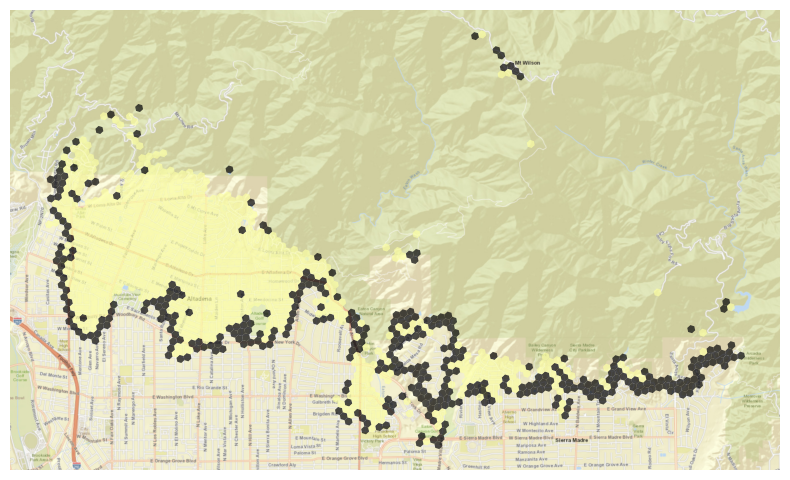

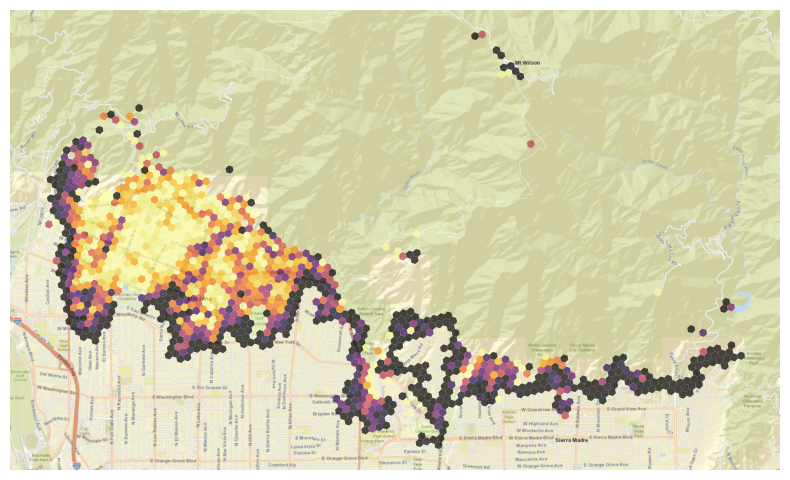

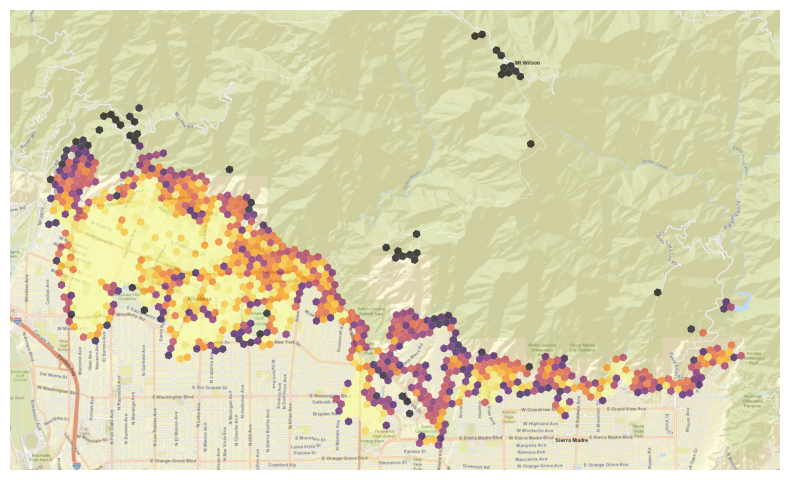

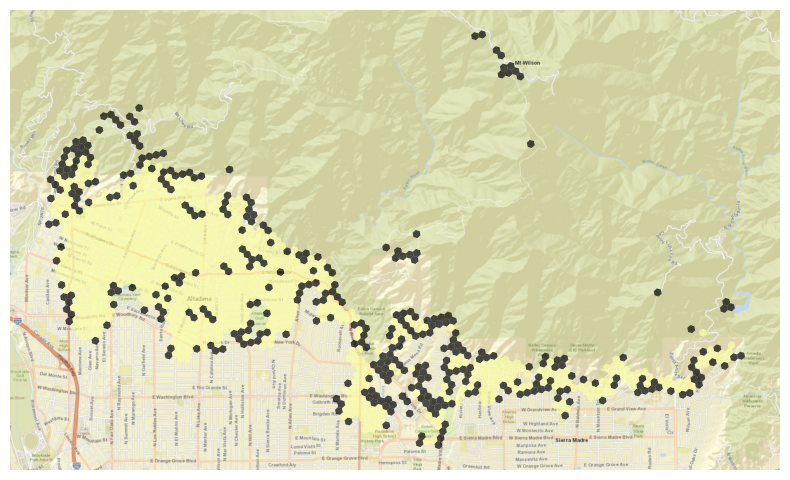

In [15]:
def save_contextily_map(gdf, column, filename, vmin=0, vmax=1):
    plot_gdf = gdf.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(8, 8))

    plot_gdf.plot(
        column=column,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        alpha=0.7,
        linewidth=0,
        edgecolor="none",
    )

    ctx.add_basemap(
        ax,
        source=ctx.providers.Esri.WorldStreetMap,
        zoom=14,
        attribution=False,
    )

    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()

save_contextily_map(eaton_plot, "actual_binary", "eaton_actual_binary.png")
save_contextily_map(eaton_plot, "actual_damage_rate", "eaton_actual_damage_rate.png")
save_contextily_map(eaton_plot, "predicted_probability", "eaton_predicted_probability.png")
save_contextily_map(eaton_plot, "predicted_binary", "eaton_predicted_binary.png")